# Six-Step Enhancement Benchmark — V3

| # | Step | Description |
|---|------|-------------|
| 0 | **Persistence baseline** | Naive Y(t) = Y(t-1) — reference for all improvements |
| 1 | **Combined multi-output** | Single `RegressorChain` predicting all 3 targets jointly |
| 2 | **Improved feature encoding** | log1p on count predictors + label-encode religion strings |
| 3 | **Shifted delta — unlock Poisson/Tweedie** | Shift ΔY by constant → all-non-negative; enables count models on delta |
| 4 | **Religion-weighted holiday score** | Weight each religion's holiday count by country religious composition |
| 5 | **All models on change-in-target** | Full 5-model benchmark predicting ΔY (shifted), reconstructed to absolute |
| 6 | **Combined: multi-output + encoding on delta** | RegressorChain + log1p encoding predicting all 3 ΔY simultaneously |

**Baseline for all comparisons**: persistence model MAE (Y(t) = Y(t-1)).
**Feature set**: V2 `+Engineered` (best from improvements_5.ipynb) unless noted.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iproduct

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import RegressorChain, MultiOutputRegressor

from utils.preprocessing_v2 import prepare_enriched_pipeline_v2, build_feature_sets_v2
from utils.ablation import MODELS
from utils.evaluators import find_top_regions, evaluate_model
from utils.features.encoding import (
    encode_religion_columns, apply_log_transforms, add_religion_weighted_holidays
)
from utils.features.improved_features import PREDICTORS_V2, COUNTRY_FEATURES, HOLIDAY_FEATURES_V2
from config import settings

HOLDOUT = 6
TOP_N   = 10
print('Imports OK')

Imports OK


In [2]:
df = prepare_enriched_pipeline_v2(clean_data=False)
top_regions    = find_top_regions(df, settings.targets, n=TOP_N)
feature_sets   = build_feature_sets_v2(df)
BEST_FEATURES  = feature_sets['+Engineered']   # V2 best feature set

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Top regions: {top_regions}')
print(f'Best feature set size: {len(BEST_FEATURES)} features')

Loading v2 enriched data from disk...
Dataset: 289,890 rows × 78 columns
Top regions: ['UKR - Donetsk', 'UKR - Kharkiv', 'UKR - Sumy', 'SYR - Idlib', 'PSX - Gaza', 'UKR - Kherson', 'BRA - Rio de Janeiro', 'SYR - Aleppo', 'UKR - Zaporizhzhia', 'UKR - Luhansk']
Best feature set size: 46 features


---
## Step 0: Persistence Baseline

Naive model: predict Y(t) = Y(t−1).  All subsequent improvements are judged
against this floor — any ML model that cannot beat this is useless.

In [3]:
def persistence_evaluate(df, region, target, holdout=HOLDOUT):
    rdf = df[df['matched_admin1_id'] == region].sort_values('month_year')
    if len(rdf) < holdout + 6:
        return None
    test    = rdf.iloc[-holdout:]
    lag_col = f'{target} (t-1)'
    if lag_col not in test.columns:
        return None
    y_test = test[target].fillna(0).values
    y_pred = test[lag_col].fillna(0).values
    mae    = mean_absolute_error(y_test, y_pred)
    nz     = y_test != 0
    mape   = (np.mean(np.abs((y_test[nz] - y_pred[nz]) / y_test[nz])) * 100
              if nz.any() else np.nan)
    return {'mae': round(mae, 2), 'mape': round(mape, 2) if not np.isnan(mape) else np.nan}

persist_records = []
for target, region in iproduct(settings.targets, top_regions):
    r = persistence_evaluate(df, region, target)
    if r:
        persist_records.append({'model': 'Persistence', 'target': target,
                                 'region': region, **r})

persist_df = pd.DataFrame(persist_records)

print('=' * 60)
print('PERSISTENCE BASELINE — mean MAE over top-10 regions')
print('=' * 60)
per_target = persist_df.groupby('target')['mae'].mean().round(2)
print(per_target.to_string())
print(f'\nOverall (all targets): {persist_df["mae"].mean():.2f}')

PERSISTENCE BASELINE — mean MAE over top-10 regions
target
Battles                       45.84
Explosions/Remote violence    88.33
Violence against civilians     3.60

Overall (all targets): 45.92


---
## Step 1: Combined Multi-Output Model (RegressorChain)

`RegressorChain` trains models sequentially:
- **Battles** → fit on features only
- **Explosions** → fit on features + predicted Battles
- **VaC** → fit on features + predicted Battles + predicted Explosions

This lets downstream targets exploit cross-target correlations that 3 independent
models miss.  Base estimator: LGBM-Tweedie (best single-target model from V2).

In [4]:
def evaluate_chain(df, region, predictors, chain_factory,
                   targets=settings.targets, holdout=HOLDOUT):
    """Train a RegressorChain and return per-target MAE."""
    rdf = df[df['matched_admin1_id'] == region].sort_values('month_year').copy()
    if len(rdf) < holdout + 6:
        return None
    avail   = [p for p in predictors if p in rdf.columns]
    train   = rdf.iloc[:-holdout]
    test    = rdf.iloc[-holdout:]
    X_train = train[avail].fillna(0)
    X_test  = test[avail].fillna(0)
    Y_train = train[targets].fillna(0)
    Y_test  = test[targets].fillna(0)
    weights = train.get('importance_weight',
                        pd.Series(1.0, index=train.index)).fillna(1)
    model = chain_factory()
    try:
        model.fit(X_train, Y_train, sample_weight=weights)
    except TypeError:
        model.fit(X_train, Y_train)
    Y_pred = np.maximum(0, model.predict(X_test))
    return {t: round(mean_absolute_error(Y_test[t], Y_pred[:, i]), 2)
            for i, t in enumerate(targets)}

tweedie_base = lambda: lgb.LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.5,
    n_estimators=200, verbose=-1)
chain_factory   = lambda: RegressorChain(tweedie_base())
indep_factory   = lambda: MultiOutputRegressor(tweedie_base())

print('Running Step 1 — RegressorChain vs Independent models...')
chain_records, indep_records = [], []

for region in top_regions:
    rc = evaluate_chain(df, region, BEST_FEATURES, chain_factory)
    ri = evaluate_chain(df, region, BEST_FEATURES, indep_factory)
    if rc and ri:
        for t in settings.targets:
            chain_records.append({'model': 'RegressorChain', 'region': region,
                                   'target': t, 'mae': rc[t]})
            indep_records.append({'model': 'Independent×3', 'region': region,
                                   'target': t, 'mae': ri[t]})

chain_df = pd.DataFrame(chain_records + indep_records)
print('Done.')

Running Step 1 — RegressorChain vs Independent models...
Done.


In [5]:
persist_means = persist_df.groupby('target')['mae'].mean()
chain_means   = pd.DataFrame(chain_records).groupby('target')['mae'].mean()
indep_means   = pd.DataFrame(indep_records).groupby('target')['mae'].mean()

step1 = pd.DataFrame({
    'Persistence': persist_means,
    'Independent×3 (Tweedie)': indep_means,
    'RegressorChain (Tweedie)': chain_means,
}).round(2)
step1['Chain vs Persist %'] = ((step1['RegressorChain (Tweedie)'] - step1['Persistence'])
                                / step1['Persistence'] * 100).round(1)
step1['Chain vs Indep %']   = ((step1['RegressorChain (Tweedie)'] - step1['Independent×3 (Tweedie)'])
                                / step1['Independent×3 (Tweedie)'] * 100).round(1)

print('=' * 72)
print('STEP 1 — Combined Multi-Output (mean MAE, top-10 regions)')
print('=' * 72)
print(step1.to_string())

overall_persist = persist_df['mae'].mean()
overall_chain   = pd.DataFrame(chain_records)['mae'].mean()
overall_indep   = pd.DataFrame(indep_records)['mae'].mean()
print(f'\nOverall  Persistence:    {overall_persist:.2f}')
print(f'Overall  Independent×3:  {overall_indep:.2f}  ({(overall_indep-overall_persist)/overall_persist*100:+.1f}% vs persist)')
print(f'Overall  RegressorChain: {overall_chain:.2f}  ({(overall_chain-overall_persist)/overall_persist*100:+.1f}% vs persist)')
print('\nNegative = better than reference')

STEP 1 — Combined Multi-Output (mean MAE, top-10 regions)
                            Persistence  Independent×3 (Tweedie)  RegressorChain (Tweedie)  Chain vs Persist %  Chain vs Indep %
target                                                                                                                          
Battles                           45.84                    50.98                     50.98                11.2               0.0
Explosions/Remote violence        88.33                   108.91                    111.53                26.3               2.4
Violence against civilians         3.60                     4.63                      4.53                25.8              -2.2

Overall  Persistence:    45.92
Overall  Independent×3:  54.84  (+19.4% vs persist)
Overall  RegressorChain: 55.68  (+21.2% vs persist)

Negative = better than reference


---
## Step 2: Improved Feature Encoding

Two fixes applied to the V2 feature set:

1. **log1p on count predictors** — ACLED event counts are zero-heavy and
   right-skewed (most regions ~0, a few have 1000+). log1p compresses the
   tail and makes tree splits more informative.

2. **LabelEncode religion columns** — `majority_religion` etc. contain WRP
   string codes (e.g. `'islmsunpct'`).  These are stored as object dtype and
   silently become NaN in sklearn's array conversion.  Label-encoding converts
   them to integers that all models can actually use.

Religion features were present in `df` but **not in any V2 feature set** —
this step also adds them to the predictor list.

In [6]:
# Build encoded dataframe
df_enc, log_col_map = apply_log_transforms(encode_religion_columns(df))

print(f'log1p columns added: {len(log_col_map)}')
print('Sample mappings:', list(log_col_map.items())[:4])

# Verify religion encoding
print()
for c in ['majority_religion', 'minority1_religion', 'minority2_religion']:
    vals = df_enc[c].dropna().unique()[:5]
    print(f'  {c}: dtype={df_enc[c].dtype}, sample={vals}')

log1p columns added: 33
Sample mappings: [('Battles (t-1)', 'log1p_Battles (t-1)'), ('Explosions/Remote violence (t-1)', 'log1p_Explosions/Remote violence (t-1)'), ('Protests (t-1)', 'log1p_Protests (t-1)'), ('Riots (t-1)', 'log1p_Riots (t-1)')]

  majority_religion: dtype=int64, sample=[-1 16  6  7  9]
  minority1_religion: dtype=int64, sample=[-1 15  9 18 11]
  minority2_religion: dtype=int64, sample=[-1 14  0  6  8]


In [7]:
RELIGION_FEATS = [
    'majority_religion', 'majority_pct',
    'minority1_religion', 'minority1_pct',
    'minority2_religion', 'minority2_pct',
    'nonreligpct',
]

def encode_feature_list(feat_list, col_map):
    """Replace count cols with their log1p versions; keep everything else."""
    return [col_map.get(f, f) for f in feat_list]

# Rebuild feature sets with encoded columns
risk_cols_raw      = [c for c in df.columns if c.startswith('risk_') and c.endswith('(t-1)')]
engineered_raw     = [
    f for f in ['Battles (t-2)', 'Explosions/Remote violence (t-2)',
                'Violence against civilians (t-2)',
                'organized_violence (t-1)', 'is_active (t-1)', 'battles_x_remote (t-1)',
                'Battles_3mo_avg (t-1)', 'Remote_3mo_avg (t-1)', 'VaC_3mo_avg (t-1)']
    if f in df.columns
]

PREDS_ENC_BASE     = encode_feature_list(PREDICTORS_V2, log_col_map) + RELIGION_FEATS
risk_enc           = encode_feature_list(risk_cols_raw, log_col_map)
country_enc        = encode_feature_list(COUNTRY_FEATURES, log_col_map)
engineered_enc     = encode_feature_list(engineered_raw, log_col_map)

feature_sets_enc = {
    'Baseline':    PREDS_ENC_BASE,
    '+Risk':       PREDS_ENC_BASE + risk_enc,
    '+Macro':      PREDS_ENC_BASE + risk_enc + settings.macro_features,
    '+Holidays':   PREDS_ENC_BASE + risk_enc + settings.macro_features + HOLIDAY_FEATURES_V2,
    '+Country':    PREDS_ENC_BASE + risk_enc + settings.macro_features + HOLIDAY_FEATURES_V2 + country_enc,
    '+Engineered': PREDS_ENC_BASE + risk_enc + settings.macro_features + HOLIDAY_FEATURES_V2 + country_enc + engineered_enc,
}

print('Encoded feature set sizes:')
for name, cols in feature_sets_enc.items():
    avail = [c for c in cols if c in df_enc.columns]
    print(f'  {name:12s}: {len(avail)} available / {len(cols)} defined')

Encoded feature set sizes:
  Baseline    : 27 available / 27 defined
  +Risk       : 34 available / 34 defined
  +Macro      : 38 available / 38 defined
  +Holidays   : 40 available / 40 defined
  +Country    : 44 available / 44 defined
  +Engineered : 53 available / 53 defined


In [8]:
# Run ablation with encoded features (best 3 models for speed)
ENC_MODELS = {
    'LGBM-Tweedie': lambda: lgb.LGBMRegressor(
        objective='tweedie', tweedie_variance_power=1.5, n_estimators=200, verbose=-1),
    'RF':           lambda: RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':      lambda: xgb.XGBRegressor(
        objective='reg:squarederror', n_estimators=200, verbosity=0),
}

fs_order = list(feature_sets_enc.keys())
combos   = list(iproduct(ENC_MODELS.keys(), fs_order, settings.targets, top_regions))
print(f'Running {len(combos)} encoded evaluations...')

enc_records = []
for i, (mname, fsname, target, region) in enumerate(combos):
    r = evaluate_model(df_enc, region, target,
                       feature_sets_enc[fsname], ENC_MODELS[mname])
    if r:
        enc_records.append({'model': mname, 'feature_set': fsname,
                             'target': target, 'region': region, **r})
    if (i + 1) % 200 == 0:
        print(f'  {i+1}/{len(combos)}...')

enc_df = pd.DataFrame(enc_records)
print('Done.')

Running 540 encoded evaluations...
  200/540...
  400/540...
Done.


In [9]:
# V2 baseline (same models, unencoded) for apples-to-apples comparison
print('Running V2 comparison (same 3 models, unencoded features)...')
v2_records = []
for i, (mname, fsname, target, region) in enumerate(
        iproduct(ENC_MODELS.keys(), list(feature_sets.keys()), settings.targets, top_regions)):
    r = evaluate_model(df, region, target,
                       feature_sets[fsname], ENC_MODELS[mname])
    if r:
        v2_records.append({'model': mname, 'feature_set': fsname,
                            'target': target, 'region': region, **r})
v2_sub = pd.DataFrame(v2_records)

# Compare best tier
best_v2  = v2_sub[v2_sub['feature_set'] == '+Engineered']
best_enc = enc_df[enc_df['feature_set'] == '+Engineered']

v2m  = best_v2.groupby(['model','target'])['mae'].mean().unstack().round(2)
encm = best_enc.groupby(['model','target'])['mae'].mean().unstack().round(2)
delta = (encm - v2m).round(2)

print('\n' + '='*72)
print('STEP 2 — Encoding improvement (+Engineered tier, mean MAE top-10 regions)')
print('='*72)
print('\nV2 (unencoded):')
print(v2m.to_string())
print('\nEncoded (log1p + religion labels):')
print(encm.to_string())
print('\nDelta (encoded − V2), negative = improvement:')
print(delta.to_string())

# vs persistence
pt = persist_df.groupby('target')['mae'].mean()
print('\nEncoded +Engineered vs Persistence baseline:')
for mname in ENC_MODELS:
    row = best_enc[best_enc['model'] == mname]
    for target in settings.targets:
        enc_mae = row[row['target'] == target]['mae'].mean()
        pst_mae = pt[target]
        print(f'  {mname:15s} | {target:35s}: enc={enc_mae:.2f}, persist={pst_mae:.2f}, '
              f'Δ={enc_mae-pst_mae:+.2f} ({(enc_mae-pst_mae)/pst_mae*100:+.1f}%)')

Running V2 comparison (same 3 models, unencoded features)...

STEP 2 — Encoding improvement (+Engineered tier, mean MAE top-10 regions)

V2 (unencoded):
target        Battles  Explosions/Remote violence  Violence against civilians
model                                                                        
LGBM-Tweedie    50.98                      108.91                        4.63
RF              57.33                      117.82                        5.08
XGBoost         52.09                      129.67                        5.10

Encoded (log1p + religion labels):
target        Battles  Explosions/Remote violence  Violence against civilians
model                                                                        
LGBM-Tweedie    50.42                      108.21                        4.67
RF              54.49                      112.37                        5.08
XGBoost         52.09                      129.67                        5.10

Delta (encoded − V2), negative

---
## Step 3: Shifted Delta Targets — Unlocking Poisson/Tweedie

**Problem**: ΔY = Y(t) − Y(t−1) can be negative.  Poisson and Tweedie
objectives require non-negative targets and throw errors on deltas.

**Fix**: compute a per-target global shift constant `s = |min(ΔY)|`.  Train
on `ΔY_shifted = ΔY + s ≥ 0`.  At inference, unshift:
`Y_pred = Y(t−1) + (model.predict(X) − s)`, then clip at 0.

This step shows the shift works and Poisson/Tweedie can now train on delta.

In [10]:
# Compute global shift constants from the full dataset
shifts = {}
for t in settings.targets:
    lag = f'{t} (t-1)'
    if lag in df.columns:
        delta = df[t] - df[lag]
        min_d = delta.min()
        shifts[t] = float(-min_d) if min_d < 0 else 0.0

# Add delta and shifted-delta columns
df_delta = df.copy()
for t in settings.targets:
    lag = f'{t} (t-1)'
    if lag in df_delta.columns:
        df_delta[f'{t}_delta']         = df_delta[t] - df_delta[lag]
        df_delta[f'{t}_delta_shifted'] = df_delta[f'{t}_delta'] + shifts[t]

print('Shift constants per target (= |min ΔY|):')
for t, s in shifts.items():
    raw_min = df_delta[f'{t}_delta'].min()
    shifted_min = df_delta[f'{t}_delta_shifted'].min()
    print(f'  {t:35s}: shift={s:.0f}  (raw min={raw_min:.0f}, shifted min={shifted_min:.0f})')

Shift constants per target (= |min ΔY|):
  Battles                            : shift=582  (raw min=-582, shifted min=0)
  Explosions/Remote violence         : shift=1004  (raw min=-1004, shifted min=0)
  Violence against civilians         : shift=149  (raw min=-149, shifted min=0)


In [11]:
def evaluate_model_delta(df_d, region, target, predictors, model_factory,
                         shift, holdout=HOLDOUT):
    """
    Train on shifted ΔY, reconstruct absolute Y at inference, measure MAE.
    The shift makes the target non-negative so Poisson/Tweedie can be used.
    """
    rdf = df_d[df_d['matched_admin1_id'] == region].sort_values('month_year').copy()
    if len(rdf) < holdout + 6:
        return None

    avail  = [p for p in predictors if p in rdf.columns]
    train  = rdf.iloc[:-holdout]
    test   = rdf.iloc[-holdout:]

    delta_col = f'{target}_delta_shifted'
    if delta_col not in rdf.columns:
        return None

    X_train = train[avail].fillna(0)
    X_test  = test[avail].fillna(0)
    y_train = train[delta_col].fillna(shift)  # fill NaN with shift (= zero delta)
    y_prev  = test[f'{target} (t-1)'].fillna(0)
    y_test  = test[target].fillna(0)
    weights = train.get('importance_weight',
                        pd.Series(1.0, index=train.index)).fillna(1)

    model = model_factory()
    try:
        model.fit(X_train, y_train, sample_weight=weights)
    except TypeError:
        model.fit(X_train, y_train)

    delta_pred = np.maximum(0, model.predict(X_test)) - shift
    y_pred     = np.maximum(0, y_prev.values + delta_pred)

    mae  = mean_absolute_error(y_test, y_pred)
    nz   = y_test != 0
    mape = (np.mean(np.abs((y_test[nz] - y_pred[nz]) / y_test[nz])) * 100
            if nz.any() else np.nan)
    return {'mae': round(mae, 2),
            'mape': round(mape, 2) if not np.isnan(mape) else np.nan}

In [12]:
# Demonstrate: Poisson + Tweedie on shifted delta (previously would crash)
DELTA_MODELS_DEMO = {
    'LGBM-Poisson': lambda: lgb.LGBMRegressor(
        objective='poisson', n_estimators=200, verbose=-1),
    'LGBM-Tweedie': lambda: lgb.LGBMRegressor(
        objective='tweedie', tweedie_variance_power=1.5, n_estimators=200, verbose=-1),
    'RF':           lambda: RandomForestRegressor(n_estimators=100, random_state=42),
}

step3_records = []
print('Running Step 3 — demo (Poisson/Tweedie on shifted delta)...')
for mname, mfac in DELTA_MODELS_DEMO.items():
    for target in settings.targets:
        for region in top_regions:
            r = evaluate_model_delta(df_delta, region, target,
                                     BEST_FEATURES, mfac, shifts[target])
            if r:
                step3_records.append({'model': mname + ' (delta)',
                                       'target': target, 'region': region, **r})

step3_df = pd.DataFrame(step3_records)

print('\n' + '='*65)
print('STEP 3 — Shifted delta: Poisson/Tweedie now work (mean MAE)')
print('='*65)
tbl3 = step3_df.groupby(['model','target'])['mae'].mean().unstack().round(2)
print(tbl3.to_string())
print()
print('Persistence reference:')
print(persist_df.groupby('target')['mae'].mean().round(2).to_string())

Running Step 3 — demo (Poisson/Tweedie on shifted delta)...

STEP 3 — Shifted delta: Poisson/Tweedie now work (mean MAE)
target                Battles  Explosions/Remote violence  Violence against civilians
model                                                                                
LGBM-Poisson (delta)    50.99                      108.07                        4.19
LGBM-Tweedie (delta)    51.61                      109.79                        4.14
RF (delta)              51.65                      120.34                        4.90

Persistence reference:
target
Battles                       45.84
Explosions/Remote violence    88.33
Violence against civilians     3.60


---
## Step 4: Religion-Weighted Holiday Encoding

Currently the V2 pipeline uses two holiday features (`holiday_count_month`,
`is_holiday_month`) that treat all holiday types identically.  A Christian
holiday in a 90% Muslim country should have near-zero effect — but the raw
count makes no distinction.

**Improvement**: `holiday_relevance_score = Σ_i  religion_i_pct × holiday_count_i`

This single feature encodes both *quantity* (how many holidays) and
*cultural relevance* (how much of the population observes them).

In [13]:
print('Building religion-weighted holiday score...')
df_rel_hol = add_religion_weighted_holidays(df)

score = df_rel_hol['holiday_relevance_score']
print(f'holiday_relevance_score: non-zero={( score > 0).sum():,}  '
      f'mean={score.mean():.4f}  max={score.max():.3f}')

# Spot-check: a heavily Muslim country should show high score on Islam holidays
eg = df_rel_hol[df_rel_hol['matched_admin1_id'].str.startswith('IRN')]
if len(eg):
    print(f'\nIran sample (expect Islamic holidays dominate):')
    print(eg[['month_year','holiday_relevance_score',
               'islam_holiday_count','christian_holiday_count']].head(6).to_string())

Building religion-weighted holiday score...
holiday_relevance_score: non-zero=127,365  mean=0.2940  max=3.760

Iran sample (expect Islamic holidays dominate):
        month_year  holiday_relevance_score  islam_holiday_count  christian_holiday_count
105210  2018-01-01                      0.0                  0.0                      0.0
105211  2018-02-01                      0.0                  0.0                      0.0
105212  2018-03-01                      0.0                  0.0                      0.0
105213  2018-04-01                      0.0                  0.0                      1.0
105214  2018-05-01                      0.0                  0.0                      0.0
105215  2018-06-01                      0.0                  0.0                      0.0


In [14]:
# Compare: raw holiday features vs religion-weighted score
FEATS_RAW_HOL = BEST_FEATURES  # includes holiday_count_month, is_holiday_month
FEATS_REL_HOL = [f for f in BEST_FEATURES
                 if f not in ('holiday_count_month', 'is_holiday_month')] + \
                ['holiday_relevance_score']

step4_raw, step4_rel = [], []
print('Running Step 4 — raw vs religion-weighted holidays (RF)...')
for target, region in iproduct(settings.targets, top_regions):
    r_raw = evaluate_model(df,         region, target, FEATS_RAW_HOL,
                            lambda: RandomForestRegressor(n_estimators=100, random_state=42))
    r_rel = evaluate_model(df_rel_hol, region, target, FEATS_REL_HOL,
                            lambda: RandomForestRegressor(n_estimators=100, random_state=42))
    if r_raw:
        step4_raw.append({'target': target, 'region': region, **r_raw})
    if r_rel:
        step4_rel.append({'target': target, 'region': region, **r_rel})

raw4  = pd.DataFrame(step4_raw).groupby('target')['mae'].mean()
rel4  = pd.DataFrame(step4_rel).groupby('target')['mae'].mean()

step4_tbl = pd.DataFrame({
    'Persistence':    persist_df.groupby('target')['mae'].mean(),
    'RF raw holidays':  raw4,
    'RF rel-weighted':  rel4,
}).round(2)
step4_tbl['Rel vs Raw %'] = ((step4_tbl['RF rel-weighted'] - step4_tbl['RF raw holidays'])
                              / step4_tbl['RF raw holidays'] * 100).round(1)
step4_tbl['Rel vs Persist %'] = ((step4_tbl['RF rel-weighted'] - step4_tbl['Persistence'])
                                   / step4_tbl['Persistence'] * 100).round(1)

print('\n' + '='*72)
print('STEP 4 — Religion-weighted holidays (RF, mean MAE, top-10 regions)')
print('='*72)
print(step4_tbl.to_string())
print('Negative % = improvement')

Running Step 4 — raw vs religion-weighted holidays (RF)...

STEP 4 — Religion-weighted holidays (RF, mean MAE, top-10 regions)
                            Persistence  RF raw holidays  RF rel-weighted  Rel vs Raw %  Rel vs Persist %
target                                                                                                   
Battles                           45.84            57.33            56.16          -2.0              22.5
Explosions/Remote violence        88.33           117.82           114.85          -2.5              30.0
Violence against civilians         3.60             5.08             5.06          -0.4              40.6
Negative % = improvement


---
## Step 5: All Models on Change-in-Target (Delta)

Full 5-model benchmark where **every model predicts ΔY_shifted** instead of
raw Y.  Advantages of the delta formulation:

- Delta series are more stationary — easier to learn
- The model only needs to predict *change*, not absolute level
- Strong autoregressive signal (Y(t−1)) is used at reconstruction time
  rather than competing with other features inside the model

All 5 models × 3 targets × 10 regions = 150 delta evaluations.

In [15]:
ALL_DELTA_MODELS = {
    'RF':           lambda: RandomForestRegressor(n_estimators=100, random_state=42),
    'LGBM-Poisson': lambda: lgb.LGBMRegressor(
        objective='poisson', n_estimators=200, verbose=-1),
    'LGBM-Tweedie': lambda: lgb.LGBMRegressor(
        objective='tweedie', tweedie_variance_power=1.5, n_estimators=200, verbose=-1),
    'XGBoost':      lambda: xgb.XGBRegressor(
        objective='reg:squarederror', n_estimators=200, verbosity=0),
    'GBR':          lambda: GradientBoostingRegressor(n_estimators=100),
}

combos5 = list(iproduct(ALL_DELTA_MODELS.keys(), settings.targets, top_regions))
print(f'Running {len(combos5)} delta evaluations...')

step5_records = []
for i, (mname, target, region) in enumerate(combos5):
    r = evaluate_model_delta(df_delta, region, target,
                             BEST_FEATURES, ALL_DELTA_MODELS[mname], shifts[target])
    if r:
        step5_records.append({'model': mname, 'target': target, 'region': region, **r})
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(combos5)}...')

step5_df = pd.DataFrame(step5_records)
print('Done.')

Running 150 delta evaluations...
  50/150...
  100/150...
  150/150...
Done.


In [16]:
# Compare delta vs raw for the same models
# Raw target results come from V2 +Engineered (from improvements_5.ipynb on disk)
ablation_v2 = pd.read_csv('outputs/ablation_results_v2.csv')
raw_best = ablation_v2[ablation_v2['feature_set'] == '+Engineered']

print('=' * 72)
print('STEP 5 — All models on delta (mean MAE, top-10 regions)')
print('=' * 72)

for target in settings.targets:
    raw_t   = raw_best[raw_best['target'] == target].groupby('model')['mae'].mean()
    delta_t = step5_df[step5_df['target'] == target].groupby('model')['mae'].mean()
    pers_t  = persist_df[persist_df['target'] == target]['mae'].mean()

    tbl = pd.DataFrame({'Raw (+Eng)': raw_t, 'Delta (shifted)': delta_t}).round(2)
    tbl['Δ vs Raw']    = (tbl['Delta (shifted)'] - tbl['Raw (+Eng)']).round(2)
    tbl['Δ vs Persist']= (tbl['Delta (shifted)'] - pers_t).round(2)
    tbl['% vs Persist']= ((tbl['Delta (shifted)'] - pers_t) / pers_t * 100).round(1)
    print(f'\n--- {target} ---  (Persistence = {pers_t:.2f})')
    print(tbl.to_string())

# Overall summary
raw_all   = raw_best.groupby('model')['mae'].mean()
delta_all = step5_df.groupby('model')['mae'].mean()
pers_all  = persist_df['mae'].mean()
summary5  = pd.DataFrame({'Raw (+Eng)': raw_all, 'Delta': delta_all}).round(2)
summary5['Δ vs Raw']    = (summary5['Delta'] - summary5['Raw (+Eng)']).round(2)
summary5['% vs Persist']= ((summary5['Delta'] - pers_all) / pers_all * 100).round(1)
print(f'\n--- OVERALL (all targets) ---  (Persistence = {pers_all:.2f})')
print(summary5.to_string())

STEP 5 — All models on delta (mean MAE, top-10 regions)

--- Battles ---  (Persistence = 45.84)
              Raw (+Eng)  Delta (shifted)  Δ vs Raw  Δ vs Persist  % vs Persist
model                                                                          
GBR                56.34            48.21     -8.13          2.37           5.2
LGBM-Poisson       50.67            50.99      0.32          5.15          11.2
LGBM-Tweedie       50.94            51.61      0.67          5.77          12.6
RF                 57.33            51.65     -5.68          5.81          12.7
XGBoost            51.11            51.74      0.63          5.90          12.9

--- Explosions/Remote violence ---  (Persistence = 88.33)
              Raw (+Eng)  Delta (shifted)  Δ vs Raw  Δ vs Persist  % vs Persist
model                                                                          
GBR               129.36           124.58     -4.78         36.25          41.0
LGBM-Poisson      114.54           108.07    

---
## Step 6: Combined — Multi-Output + Encoding on Delta

Brings together Steps 1, 2, and 5:

- **Multi-output**: `RegressorChain` predicting all 3 ΔY simultaneously
- **Encoded features**: log1p count columns + label-encoded religion (Step 2)
- **Delta targets**: shifted ΔY to enable Poisson/Tweedie (Steps 3/5)

Targets: reconstructed absolute values for MAE comparison against persistence.

In [17]:
# Build encoded + delta dataframe
df_enc_delta, _lmap = apply_log_transforms(encode_religion_columns(df))

# Add shifted delta columns
for t in settings.targets:
    lag = f'{t} (t-1)'
    if lag in df_enc_delta.columns:
        df_enc_delta[f'{t}_delta']         = df_enc_delta[t] - df_enc_delta[lag]
        df_enc_delta[f'{t}_delta_shifted'] = df_enc_delta[f'{t}_delta'] + shifts[t]

BEST_ENC_FEATS = feature_sets_enc['+Engineered']
print(f'Encoded +Engineered feature count: '
      f'{len([f for f in BEST_ENC_FEATS if f in df_enc_delta.columns])}')

Encoded +Engineered feature count: 53


In [18]:
def evaluate_chain_delta(df_d, region, predictors, chain_factory,
                          shifts, targets=settings.targets, holdout=HOLDOUT):
    """RegressorChain on shifted ΔY for all targets; returns absolute-MAE per target."""
    rdf = df_d[df_d['matched_admin1_id'] == region].sort_values('month_year').copy()
    if len(rdf) < holdout + 6:
        return None

    avail  = [p for p in predictors if p in rdf.columns]
    train  = rdf.iloc[:-holdout]
    test   = rdf.iloc[-holdout:]

    delta_cols = [f'{t}_delta_shifted' for t in targets]
    if not all(c in rdf.columns for c in delta_cols):
        return None

    X_train  = train[avail].fillna(0)
    X_test   = test[avail].fillna(0)
    dY_train = train[delta_cols].fillna(
        pd.Series({f'{t}_delta_shifted': shifts[t] for t in targets}))
    weights  = train.get('importance_weight',
                         pd.Series(1.0, index=train.index)).fillna(1)

    model = chain_factory()
    try:
        model.fit(X_train, dY_train, sample_weight=weights)
    except TypeError:
        model.fit(X_train, dY_train)

    dY_pred = np.maximum(0, model.predict(X_test))   # shape (holdout, n_targets)

    results = {}
    for i, t in enumerate(targets):
        y_prev  = test[f'{t} (t-1)'].fillna(0).values
        y_test  = test[t].fillna(0).values
        d_pred  = dY_pred[:, i] - shifts[t]
        y_pred  = np.maximum(0, y_prev + d_pred)
        results[t] = round(mean_absolute_error(y_test, y_pred), 2)
    return results

In [19]:
S6_CONFIGS = {
    'Chain-Tweedie (enc+delta)': lambda: RegressorChain(
        lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5,
                          n_estimators=200, verbose=-1)),
    'Chain-RF (enc+delta)':      lambda: RegressorChain(
        RandomForestRegressor(n_estimators=100, random_state=42)),
}

step6_records = []
print('Running Step 6 — combined (multi-output + encoded + delta)...')
for cname, cfac in S6_CONFIGS.items():
    for region in top_regions:
        r = evaluate_chain_delta(df_enc_delta, region,
                                  BEST_ENC_FEATS, cfac, shifts)
        if r:
            for t in settings.targets:
                step6_records.append({'model': cname, 'region': region,
                                       'target': t, 'mae': r[t]})
print('Done.')

Running Step 6 — combined (multi-output + encoded + delta)...
Done.


In [20]:
step6_df = pd.DataFrame(step6_records)

print('=' * 72)
print('STEP 6 — Multi-output + Encoding + Delta (mean MAE, top-10 regions)')
print('=' * 72)
for target in settings.targets:
    sub = step6_df[step6_df['target'] == target]
    pers = persist_df[persist_df['target'] == target]['mae'].mean()
    print(f'\n--- {target} ---  (Persistence = {pers:.2f})')
    tbl = sub.groupby('model')['mae'].mean().round(2).to_frame()
    tbl['vs Persist %'] = ((tbl['mae'] - pers) / pers * 100).round(1)
    print(tbl.to_string())

pers_all = persist_df['mae'].mean()
print(f'\n--- OVERALL ---  (Persistence = {pers_all:.2f})')
tbl_all = step6_df.groupby('model')['mae'].mean().round(2).to_frame()
tbl_all['vs Persist %'] = ((tbl_all['mae'] - pers_all) / pers_all * 100).round(1)
print(tbl_all.to_string())

STEP 6 — Multi-output + Encoding + Delta (mean MAE, top-10 regions)

--- Battles ---  (Persistence = 45.84)
                             mae  vs Persist %
model                                         
Chain-RF (enc+delta)       48.84           6.6
Chain-Tweedie (enc+delta)  52.56          14.7

--- Explosions/Remote violence ---  (Persistence = 88.33)
                              mae  vs Persist %
model                                          
Chain-RF (enc+delta)       112.90          27.8
Chain-Tweedie (enc+delta)  114.97          30.2

--- Violence against civilians ---  (Persistence = 3.60)
                           mae  vs Persist %
model                                       
Chain-RF (enc+delta)       4.7          30.5
Chain-Tweedie (enc+delta)  4.5          25.0

--- OVERALL ---  (Persistence = 45.92)
                             mae  vs Persist %
model                                         
Chain-RF (enc+delta)       55.48          20.8
Chain-Tweedie (enc+delta)  57.35  

---
## Final Summary

In [21]:
rows = []

# Persistence
rows.append({'Step': 'Step 0 — Persistence (baseline)', **{t: round(persist_df[persist_df['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(persist_df['mae'].mean(), 2)})

# Step 1 — best multi-output (chain)
c1 = pd.DataFrame(chain_records)
rows.append({'Step': 'Step 1 — RegressorChain (Tweedie)', **{t: round(c1[c1['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(c1['mae'].mean(), 2)})

# Step 2 — best encoded model (+Engineered)
best_enc2 = enc_df[(enc_df['feature_set']=='+Engineered') & (enc_df['model']=='LGBM-Tweedie')]
rows.append({'Step': 'Step 2 — Encoded features (Tweedie)', **{t: round(best_enc2[best_enc2['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(best_enc2['mae'].mean(), 2)})

# Step 4 — religion-weighted holidays (RF)
rows.append({'Step': 'Step 4 — Rel-weighted holidays (RF)', **{t: round(rel4[t],2) for t in settings.targets},
             'Overall': round(pd.DataFrame(step4_rel)['mae'].mean(), 2)})

# Step 5 — best delta model
best_delta_model = step5_df.groupby('model')['mae'].mean().idxmin()
s5best = step5_df[step5_df['model'] == best_delta_model]
rows.append({'Step': f'Step 5 — Delta target ({best_delta_model})', **{t: round(s5best[s5best['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(s5best['mae'].mean(), 2)})

# Step 6 — combined
best_s6_model = step6_df.groupby('model')['mae'].mean().idxmin()
s6best = step6_df[step6_df['model'] == best_s6_model]
rows.append({'Step': f'Step 6 — Combined ({best_s6_model})', **{t: round(s6best[s6best['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(s6best['mae'].mean(), 2)})

summary = pd.DataFrame(rows).set_index('Step')
persist_row = summary.loc['Step 0 — Persistence (baseline)']

print('=' * 80)
print('FINAL SUMMARY — Mean MAE (top-10 regions, 6-month holdout)')
print('=' * 80)
print(summary.to_string())
print()
print('% improvement vs persistence (negative = better):')
pct_tbl = ((summary - persist_row) / persist_row * 100).round(1)
pct_tbl.loc['Step 0 — Persistence (baseline)'] = 0.0
print(pct_tbl.to_string())

os.makedirs('outputs', exist_ok=True)
summary.to_csv('outputs/improvements_6_summary.csv')
print('\nSaved: outputs/improvements_6_summary.csv')

FINAL SUMMARY — Mean MAE (top-10 regions, 6-month holdout)
                                          Battles  Explosions/Remote violence  Violence against civilians  Overall
Step                                                                                                              
Step 0 — Persistence (baseline)             45.84                       88.33                        3.60    45.92
Step 1 — RegressorChain (Tweedie)           50.98                      111.53                        4.53    55.68
Step 2 — Encoded features (Tweedie)         50.42                      108.21                        4.67    54.43
Step 4 — Rel-weighted holidays (RF)         56.16                      114.85                        5.06    58.69
Step 5 — Delta target (LGBM-Poisson)        50.99                      108.07                        4.19    54.42
Step 6 — Combined (Chain-RF (enc+delta))    48.83                      112.90                        4.70    55.48

% improvement vs per

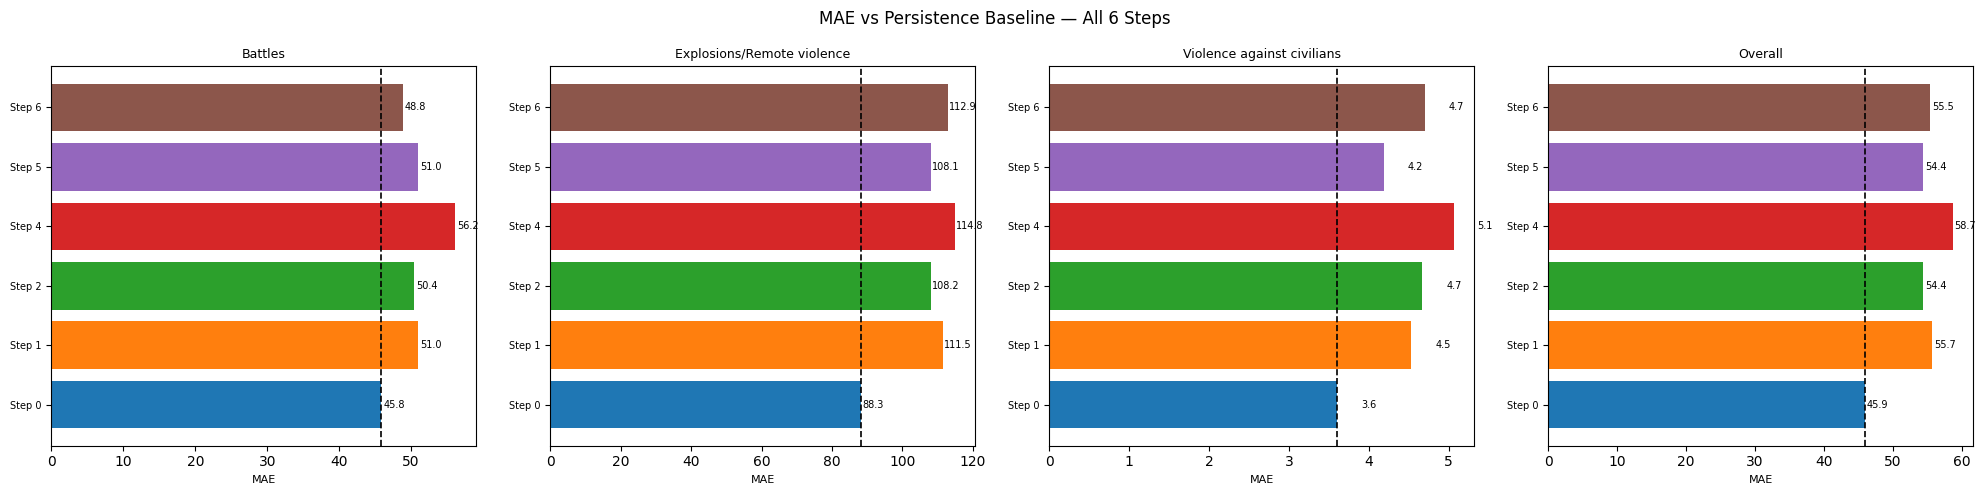

Saved: outputs/figures/improvements_6_summary.png


In [22]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('MAE vs Persistence Baseline — All 6 Steps', fontsize=12)

cols_plot = settings.targets + ['Overall']
colors = plt.cm.tab10.colors

for ax, col in zip(axes, cols_plot):
    vals  = summary[col]
    pbase = vals.iloc[0]  # persistence
    bars  = ax.barh(range(len(vals)), vals.values, color=colors[:len(vals)])
    ax.axvline(pbase, color='black', linestyle='--', linewidth=1.2, label='Persistence')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([s.split('—')[0].strip() for s in vals.index], fontsize=7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('MAE', fontsize=8)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=7)

plt.tight_layout()
os.makedirs('outputs/figures', exist_ok=True)
plt.savefig('outputs/figures/improvements_6_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/improvements_6_summary.png')